In [30]:
import pandas as pd
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [2]:
dataset_df = pd.read_csv('../data/dataset.csv')
taxonomy_df = pd.read_csv('../data/taxonomy.csv')

In [3]:
dataset_df.head()

,Unnamed: 0,title,section,name
0,0,Replacing two rubber mounts (rear) for rear ax...,Engine,Engine Mount
1,1,Disassembling and assembling cylinder head/mou...,Engine,Cylinder Head
2,2,Remove and install/replace the right exhaust c...,Engine,Camshaft
3,3,Replacing camshaft,Engine,Camshaft
4,4,Rear brakes service,Brakes,Brakes


In [4]:
taxonomy_df.head()

,section,name
0,Brakes,Disc Brake Caliper
1,Brakes,Brake Drum
2,Brakes,Brakes
3,Lighting,Headlamp Alignment
4,Lighting,Headlamp Bulb


In [9]:
print(len(dataset_df))
print(len(taxonomy_df))

202
45


In [8]:
# ensure no duplicate taxonomy rows
total_rows = len(taxonomy_df)
num_unique_combinations = len(taxonomy_df.drop_duplicates(subset=['section', 'name']))
print(total_rows == num_unique_combinations)

True


In [10]:
# check for null values or 'unknown' anywhere in source files
dataset_null_total = dataset_df.isna().sum().sum()
dataset_unknown_total = (dataset_df == "Unknown").sum().sum() + (dataset_df == "unknown").sum().sum()

taxonomy_null_total = taxonomy_df.isna().sum().sum()
taxonomy_unknown_total = (taxonomy_df == "Unknown").sum().sum() + (taxonomy_df == "unknown").sum().sum()

print(f"Total dataset missing (None or NaN): {dataset_null_total}")
print(f'Total dataset "Unknown" strings: {dataset_unknown_total}')

print(f"Total taxonomy missing (None or NaN): {taxonomy_null_total}")
print(f'Total taxonomy"Unknown" strings: {taxonomy_unknown_total}')

Total dataset missing (None or NaN): 0
Total dataset "Unknown" strings: 30
Total taxonomy missing (None or NaN): 0
Total taxonomy"Unknown" strings: 0


In [21]:
# explore title strings

titles = dataset_df['title'].tolist()

shortest_title = min(titles, key=lambda s: len(s.split()))
longest_title = max(titles, key=lambda s: len(s.split()))

min_len = len(shortest_title.split())
max_len = len(longest_title.split())
avg_num_words = sum(len(s.split()) for s in titles) / len(titles)

print(f"Title length — Min: {min_len}, Max: {max_len}, Average: {avg_num_words:.2f}")

Title length — Min: 2, Max: 16, Average: 7.83


In [22]:
# quick sanity check
print(shortest_title)
print(longest_title)

Replacing camshaft
Replace LEDs of both control units for headliner lighting (AW specification without programming/coding, see 61 00...)


In [18]:
# what's the corpus size for the title look like?
full_string_list = dataset_df['title'].tolist()

all_words_with_dupes = ' '.join(full_string_list)

unique_words = set(all_words_with_dupes.split())

print(f"There are {len(unique_words)} unique words across all {len(dataset_df)} titles")



There are 326 unique words across all 202 titles


Interesting - that's a lot of word re-use. Which, given the context, makes sense. It also has implications:

Our titles have high lexical overlap and a limited overall vocabulary. Embeddings could easily get things wrong - and be "too much" for this small dataset as well. For feature engineering, bigrams and count frequency data (like TF-IDF) should be a strong fit.

In [24]:
# do we have at least one of each taxonomy example in the dataset?
# better, how many of each are represented?

# Step 1: Count occurrences of each (section, name) pair in dataset_df
counts = dataset_df.groupby(['section', 'name']).size().reset_index(name='count')

# Step 2: Merge these counts into taxonomy_df
taxonomy_with_counts = taxonomy_df.merge(counts, on=['section', 'name'], how='left')

# Step 3: Fill in 0s for any (section, name) pairs not found in dataset_df
taxonomy_with_counts['count'] = taxonomy_with_counts['count'].fillna(0).astype(int)


In [25]:
print(taxonomy_with_counts)

     section                                       name  count
0     Brakes                         Disc Brake Caliper     15
1     Brakes                                 Brake Drum      0
2     Brakes                                     Brakes     17
3   Lighting                         Headlamp Alignment     11
4   Lighting                              Headlamp Bulb      0
5   Lighting                             Signal Flasher      0
6     Brakes  Disc Brake Caliper & Pad Sliding Surfaces      0
7   Lighting                              Interior Bulb     37
8   Lighting                              Exterior Bulb     48
9   Lighting                    Headlamp Control Module      0
10    Brakes               Disc Brake Caliper Guide Pin      0
11  Lighting                              Fog Lamp Bulb      2
12    Brakes                         Parking Brake Pads      0
13  Lighting                             Fog Lamp Relay      0
14  Lighting                                  Dome Lamp

In [27]:
# That's not looking good - how many taxonomy labels have 0 dataset examples?
num_unmatched = (taxonomy_with_counts['count'] == 0).sum()
print(f"Of the {len(taxonomy_with_counts)} taxonomy labels, {num_unmatched} have 0 dataset examples.")

Of the 45 taxonomy labels, 33 have 0 dataset examples.


In [28]:
# So most labels aren't represented in the training dataset.
# Let's examine the ones that are.

nonzero_labels = taxonomy_with_counts[taxonomy_with_counts['count'] > 0]
nonzero_labels_sorted = nonzero_labels.sort_values('count', ascending=True)

for _, row in nonzero_labels_sorted.iterrows():
    section = row['section']
    name = row['name']
    count = row['count']
    
    print(f"\nSection: {section}, Name: {name} — Count: {count}")
    
    matching_titles = dataset_df[
        (dataset_df['section'] == section) & 
        (dataset_df['name'] == name)
    ]['title'].tolist()
    
    for title in matching_titles:
        print(f"  - {title}")



Section: Brakes, Name: Drum Brake Backing Plate — Count: 1
  - Removing and installing/renewing a brake anchor plate/brake guard plate at rear

Section: Lighting, Name: Fog Lamp Bulb — Count: 2
  - Replacing halogen bulb for left or right front fog lamp
  - Replacing LED fog light, left

Section: Lighting, Name: Foglamp Alignment — Count: 3
  - Checking front light combination for tightness (headlight removed)
  - Adjusting foglights
  - Adjusting fog lights

Section: Lighting, Name: Side Marker/Fog Lamp Assembly — Count: 10
  - Removing and installing/replacing front left or right additional turn signal lamp (coupé, convertible, compact)
  - Removing and installing/replacing rear reflector at rear (on bumper cover, rear)
  - Adjusting fog lamps
  - Removing and refitting left-hand front fog light (LED type from 07/13 on)
  - Removing and installing/replacing complete front left turn signal lamp
  - Removing and installing/replacing front left or right side marker light (M roadster, a

/var/folders/6c/8xn6nhwd35v6zhd42xl4dpr40000gn/T/ipykernel_53436/4218641617.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nonzero['label'] = nonzero['section'] + ' / ' + nonzero['name']


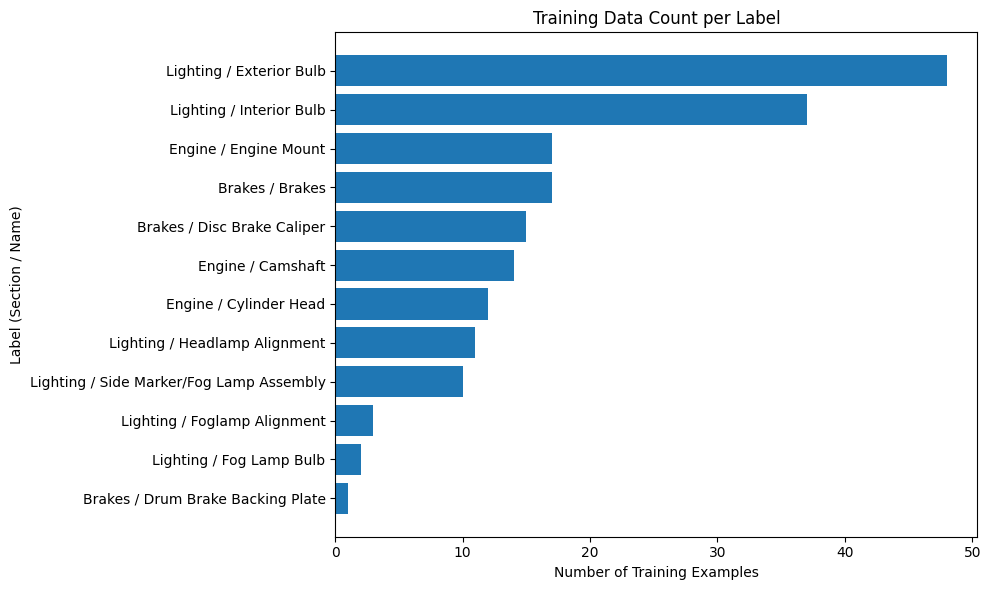

In [31]:
# visualize it

# Use only nonzero labels
nonzero = taxonomy_with_counts[taxonomy_with_counts['count'] > 0]

# Create a unique label name for plotting
nonzero['label'] = nonzero['section'] + ' / ' + nonzero['name']

# Sort by count
nonzero_sorted = nonzero.sort_values('count', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(nonzero_sorted['label'], nonzero_sorted['count'])
plt.xlabel('Number of Training Examples')
plt.ylabel('Label (Section / Name)')
plt.title('Training Data Count per Label')
plt.tight_layout()
plt.show()

### Model Choice

Contenders:

- Linear SVC (Macro-F1 of 0.71) - our winner
- Logistic Regression (Macro-F1 of 0.60)
- Multinomial Naive Bayes (Macro-F1 of 0.43)

- Random Forest (RFC): Did not try; slow and prone to overfitting on small datasets
- XGBoost: Did not try; while it's often an exceptional choice, it's overkill here and likely slow
- KNN: Doesn't scale, doesn't support confidence scoring meaningfully for this task

### Results

As shown in the plot: While the training dataset titles have high lexical overlap and a limited overall vocabulary, there's another complication: the training dataset has an imbalanced and very sparse label distribution. 

Implication 1: A TF-IDF + Linear SVC is NOT a good enough choice *by itself*. That system would only ever predict the 12 labels represented in the training dataset and be strongly biased toward predicting "Lighting / Exterior Bulb" and "Lighting / Interior Bulb", which is very undesirable.

Hybrid, open-set-aware solution: 

Setup: Embed all 45 labels and store them
Training: train on the 12 known labels only, as this is all that's possible

Inference:
1. Let classifier predict label. (It will only predict one of the 12)
1a. If the prediction's confidence score is above a threshold, use it
1b. If not, use embedding and cosine similarity (step 2)

2. Embed the title and use cosine similarity with all 45 labels.
2a. If the highest-scoring label is above a second threshold, use it
2b. If not, use "unknown"

This gives us a solution that:
- uses the lightweight classifier when possible
- uses fallback semantic similarity when necessary to achieve representation for labels not known to the classifier
- greatly reduces the need for predicting "unknown", but keeps it to prevent low-quality predictions.

However:

SVC on its own doesn't natively support predict_proba(), needed for my threshold-based approach. So I'll wrap it with CalibratedClassifierCV, which calibrates its outputs and gives me probabilistic predictions, supporting the fallback thresholding logic. And because this wrapper internally does 5-fold cross-validation, we need to explicitly lower that number to accommodate labels with less than 5 samples in the dataset.

Requirements:
- use config file to allow for easy experimentation and exploraiton in the future as more data becomes available
- use stratified train/test splitting (will require filtering labels with only 1 occurrence out of the train set, but there's currently only one (Brakes :: Drum Brake Backing Plate) - and as long as the dataset is so uneven, stratification is the best split choice)
- tune values for classifier threshold and embedding-similarity threshold to optimize results